# Evaluate promoted RBF SVC on held-out test set

Evaluates the currently promoted Flow model (`src/models/flow/active.onnx`) against the held-out processed test split from `2026-06-02-20-08`.

The test split was not used for training or validation. Metrics below should be treated as final held-out performance for this promoted artifact/data snapshot.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)

TEST_DATA_PATH = Path("../data/processed/2026-06-02-20-08.processed.test.csv")
MODEL_PATH = Path("../../src/models/flow/active.onnx")
METADATA_PATH = Path("../../src/models/flow/active.metadata.json")

assert TEST_DATA_PATH.exists(), TEST_DATA_PATH.resolve()
assert MODEL_PATH.exists(), MODEL_PATH.resolve()
assert METADATA_PATH.exists(), METADATA_PATH.resolve()


## Load test split and model metadata

In [2]:
test_frame = pd.read_csv(TEST_DATA_PATH)
metadata = json.loads(METADATA_PATH.read_text())
feature_columns = metadata["feature_columns"]
classes = metadata["classes"]

missing = [column for column in feature_columns + [metadata["target_column"]] if column not in test_frame.columns]
assert not missing, f"Missing required columns: {missing}"

print(f"Rows: {len(test_frame):,}")
print(f"Features: {len(feature_columns):,}")
print(f"Active model: {metadata.get('promoted_model_name') or metadata.get('model_name')}")
print(f"ONNX file: {metadata.get('onnx_file')}")
display(pd.DataFrame({"feature": feature_columns}))
display(test_frame[metadata["target_column"]].value_counts().to_frame("rows"))
display(test_frame.head())


Rows: 228
Features: 12
Active model: rbf_svc
ONNX file: active.onnx


,feature
0,difficulty
1,meta_previous_difficulty
2,meta_jump_key_presses
3,meta_left_key_presses
4,meta_right_key_presses
5,meta_total_horizontal_movement_px
6,meta_skip_reward_total
7,meta_skipped_platforms
8,device_type_desktop
9,device_type_mobile


,rows
challenge_label,
appropriately_challenged,111
under_challenged,71
over_challenged,46


,window_index,difficulty,score,height_climbed,challenge_label,meta_deaths,meta_skip_reward,meta_deaths_total,meta_jump_key_presses,meta_left_key_presses,meta_right_key_presses,meta_skip_reward_total,meta_skipped_platforms,meta_seconds_since_flag,meta_previous_difficulty,meta_vertical_position_y,meta_failed_jump_attempts,meta_distinct_failed_jumps,meta_flags_collected_total,meta_new_platforms_reached,meta_platform_gap_y_avg_px,meta_platform_gap_y_max_px,meta_platform_gap_y_min_px,meta_platform_width_avg_px,meta_platform_width_max_px,meta_platform_width_min_px,meta_window_starting_height,meta_platform_x_shift_max_px,meta_platform_x_shift_min_px,meta_platform_speed_px_per_frame,meta_total_horizontal_movement_px,meta_jumps_landed_on_new_platforms,meta_repeated_failed_jump_attempts,height_delta,deaths_delta,device_type_desktop,device_type_mobile
0,34.0,10.0,62.0,9719.0,under_challenged,0,0,30,4,7,8,4,0,2.393,10,-8988,0,0,88,4,132,144,120,55,80,30,9415,250,200,1.2,708,4,0,304.0,0,0,1
1,27.0,10.0,71.0,11256.0,appropriately_challenged,2,0,31,8,5,6,6,0,0.412,10,-10533,2,2,96,7,132,144,120,55,80,30,10462,250,200,1.2,1249,7,0,794.0,2,0,1
2,93.0,10.0,-122.0,8809.0,over_challenged,2,0,206,4,5,5,2,0,10.642,10,-7955,2,1,82,0,132,144,120,55,80,30,8682,250,200,1.2,750,2,1,127.0,2,0,1
3,72.0,10.0,115.0,16418.0,under_challenged,0,0,35,3,10,7,0,0,2.042,10,-15694,0,0,150,3,132,144,120,55,80,30,16125,250,200,1.2,745,3,0,293.0,0,0,1
4,47.0,10.0,-37.0,1123.0,over_challenged,5,0,49,3,1,6,2,0,2.758,10,-390,5,1,10,1,132,144,120,55,80,30,1123,250,200,1.2,930,0,4,0.0,5,0,1


## Run ONNX inference

In [3]:
try:
    import onnxruntime as ort
except ImportError as error:
    raise ImportError("Install onnxruntime in the notebook environment to run held-out evaluation.") from error

x_test = test_frame[feature_columns].astype(np.float32).to_numpy()
y_true = test_frame[metadata["target_column"]].astype(str).to_numpy()

session = ort.InferenceSession(str(MODEL_PATH), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: x_test})
output_names = [output.name for output in session.get_outputs()]
print(output_names)

output_by_name = dict(zip(output_names, outputs, strict=True))
if "label" in output_by_name:
    labels = output_by_name["label"]
    if np.issubdtype(labels.dtype, np.number):
        y_pred = np.array([classes[int(label)] for label in labels])
    else:
        y_pred = labels.astype(str)
elif "probabilities" in output_by_name:
    probabilities = output_by_name["probabilities"]
    y_pred = np.array([classes[index] for index in probabilities.argmax(axis=1)])
else:
    first_output = outputs[0]
    if first_output.ndim == 1:
        y_pred = np.array([classes[int(label)] for label in first_output])
    else:
        y_pred = np.array([classes[index] for index in first_output.argmax(axis=1)])

print(f"Predictions: {len(y_pred):,}")
display(pd.Series(y_pred, name="predicted_label").value_counts().to_frame("rows"))


['label', 'probabilities']
Predictions: 228


,rows
predicted_label,
appropriately_challenged,103
under_challenged,77
over_challenged,48


## Held-out test metrics

In [4]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}
metrics_frame = pd.Series(metrics).to_frame("score")
display(metrics_frame)

report = classification_report(y_true, y_pred, labels=classes, target_names=classes, output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)


,score
accuracy,0.903509
balanced_accuracy,0.909333
precision_macro,0.894103
recall_macro,0.909333
f1_macro,0.900656
precision_weighted,0.905138
recall_weighted,0.903509
f1_weighted,0.903154


,precision,recall,f1-score,support
appropriately_challenged,0.932039,0.864865,0.897196,111.000000
over_challenged,0.854167,0.891304,0.872340,46.000000
under_challenged,0.896104,0.971831,0.932432,71.000000
accuracy,0.903509,0.903509,0.903509,0.903509
macro avg,0.894103,0.909333,0.900656,228.000000
weighted avg,0.905138,0.903509,0.903154,228.000000


## Confusion matrix

predicted,appropriately_challenged,over_challenged,under_challenged
actual,,,
appropriately_challenged,96,7,8
over_challenged,5,41,0
under_challenged,2,0,69


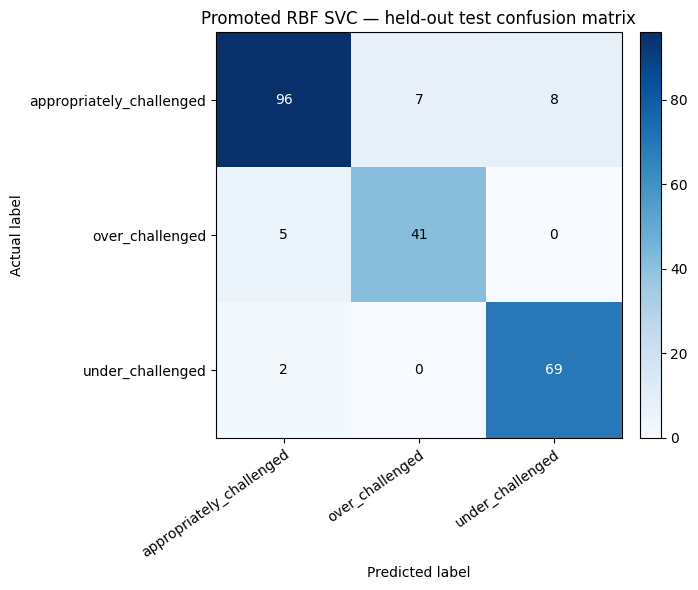

In [5]:
confusion = confusion_matrix(y_true, y_pred, labels=classes)
confusion_frame = pd.DataFrame(confusion, index=pd.Index(classes, name="actual"), columns=pd.Index(classes, name="predicted"))
display(confusion_frame)

def plot_confusion_matrix(matrix, labels):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, interpolation="nearest", cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        title="Promoted RBF SVC — held-out test confusion matrix",
        xlabel="Predicted label",
        ylabel="Actual label",
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")
    threshold = matrix.max() / 2 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, int(matrix[row, col]), ha="center", va="center", color="white" if matrix[row, col] > threshold else "black")
    fig.tight_layout()
    plt.show()

plot_confusion_matrix(confusion, classes)


## Errors for inspection

In [6]:
errors = test_frame.copy()
errors["predicted_label"] = y_pred
errors = errors[errors[metadata["target_column"]].ne(errors["predicted_label"])]
print(f"Errors: {len(errors):,} / {len(test_frame):,}")
inspection_cols = [
    metadata["target_column"], "predicted_label", "difficulty", "meta_previous_difficulty",
    "deaths_delta", "height_delta", "meta_jump_key_presses", "meta_left_key_presses",
    "meta_right_key_presses", "meta_total_horizontal_movement_px", "meta_skip_reward_total",
    "meta_skipped_platforms", "device_type_desktop", "device_type_mobile",
]
inspection_cols = [column for column in inspection_cols if column in errors.columns]
display(errors[inspection_cols].head(50))


Errors: 22 / 228


,challenge_label,predicted_label,difficulty,meta_previous_difficulty,deaths_delta,height_delta,meta_jump_key_presses,meta_left_key_presses,meta_right_key_presses,meta_total_horizontal_movement_px,meta_skip_reward_total,meta_skipped_platforms,device_type_desktop,device_type_mobile
1,appropriately_challenged,under_challenged,10.0,10,2,794.0,8,5,6,1249,6,0,0,1
15,appropriately_challenged,over_challenged,9.0,9,3,283.0,4,1,3,1342,0,0,0,1
25,over_challenged,appropriately_challenged,10.0,10,4,126.0,5,8,8,1444,12,0,1,0
45,appropriately_challenged,over_challenged,10.0,10,3,252.0,5,0,7,937,2,0,0,1
52,appropriately_challenged,under_challenged,10.0,10,0,175.0,3,3,3,706,0,0,0,1
64,appropriately_challenged,under_challenged,8.0,8,0,160.0,4,5,3,1303,0,0,0,1
68,appropriately_challenged,under_challenged,10.0,10,0,177.0,10,8,4,991,2,0,0,1
69,over_challenged,appropriately_challenged,10.0,10,2,0.0,4,6,5,1603,10,0,1,0
74,appropriately_challenged,under_challenged,10.0,10,0,120.0,4,7,4,1248,0,0,0,1
75,appropriately_challenged,under_challenged,10.0,10,1,568.0,5,6,5,1229,6,0,1,0


## Save evaluation summary (optional)

In [7]:
summary = {
    "model_path": str(MODEL_PATH),
    "metadata_path": str(METADATA_PATH),
    "test_data_path": str(TEST_DATA_PATH),
    "rows": int(len(test_frame)),
    "features": feature_columns,
    "classes": classes,
    "metrics": {key: float(value) for key, value in metrics.items()},
    "confusion_matrix": confusion.astype(int).tolist(),
}
summary_path = Path("../models/promoted_rbf_svc_2026-06-02-20-08_test_evaluation.json")
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n")
print(summary_path)


SyntaxError: unterminated string literal (detected at line 12) (853416649.py, line 12)